# VAR Parameter Estimation

The Vector Auto Regressive Process is a generalization of the single variable Autoregressive (AR) process to multiple variables. The $\text{VAR}(n)$ </br> 
is defined by,

$
\begin{align}
X_t = \mathcal{M} + \Phi_1 X_{t-1} \Phi_2 X_{t-2} + \cdots + \Phi_n X_{t-n} + \mathcal{E}_t
\end{align}
\tag{1}
$

where $t = 1, 2, 3, \ldots, T$, $X_t$ is column vector of length $m$ representing the time series, $\mathcal{M}$ is a $m$ element constant offset column vector, $\Phi_t$ are $m \times m$ matrices denoting constant coefficients and $\mathcal{E}_t$ an a random column normal vector with zero mean and covariance matrix $\Omega$,

$
\begin{align}
\mathcal{E}_t \sim \text{Normal}(0, \Omega)
\end{align}
\tag{2}
$

It follows that,

$
\begin{align}
\text{Cov}(\mathcal{E}_t, \mathcal{E}_s) = \Omega 
\end{align}
\tag{3}
$

Given a multivariate time series $X_t$ the following parameters are estimated: $\mathcal{M}$, $\Phi_n$ and $\Omega$. Here simulations are performed for specified values of the parameters and estimation methods the take the simulated $X_t$ as input are tested by comparing the result to the values specified .

## Imports

In [3]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot
import numpy

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import var, stats
from lib.plots import stack, fpoints, fcurve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [4]:
def comparison_plot(xt, title, ylim=(-2.5, 2.5), xlim=(0, 1000)):
    ylabels = [f"$S_{i+1}(t)$" for i in range(len(xt))]
    stack(xt, ylim=ylim, xlim=xlim, title=title, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), title_offset=0.2, lw=1)

## $\text{VAR}(1)$ Simulations

### Uncoupled $\text{AR}(1)$

In [5]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])

npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [6]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

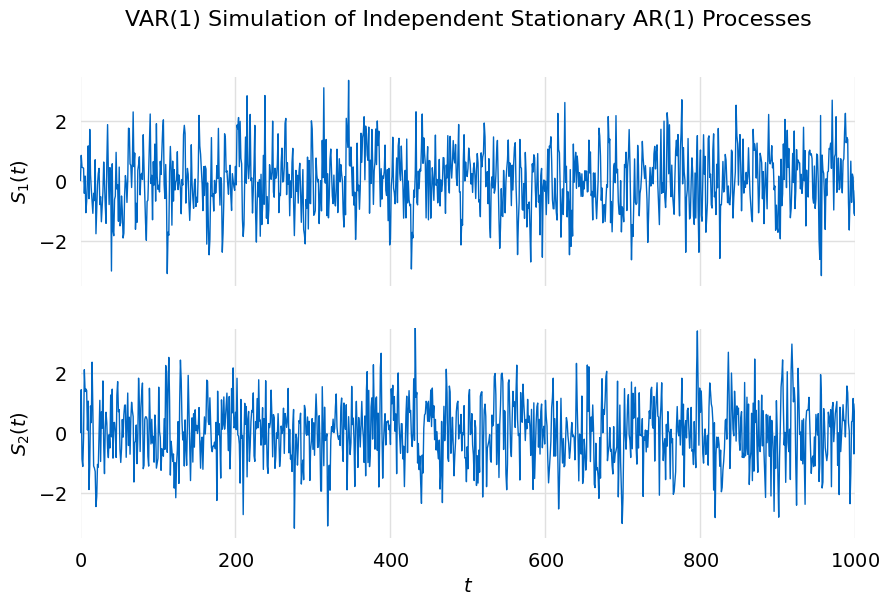

In [7]:
title = f"VAR(1) Simulation of Independent Stationary AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [8]:
result, result_model = var.compute_order_estimate(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.1849,0.1875,1.203,0.1858
1,0.05108*,0.05890*,1.052*,0.05382*
2,0.05239,0.06543,1.054,0.05696
3,0.05189,0.07015,1.053,0.05829
4,0.05184,0.07532,1.053,0.06007


In [9]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderEst__est_id": "a5fd4529-266f-4761-8994-f0499d8bf830",
   "_VAROrderEst__order": 1,
   "_VAROrderEst__aic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "AIC",
      "_LagOrderEst__value": 0.051077623719978184,
      "_LagOrderEst__est_id": "a5fd4529-266f-4761-8994-f0499d8bf830"
   },
   "_VAROrderEst__bic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "BIC",
      "_LagOrderEst__value": 0.058903555911225744,
      "_LagOrderEst__est_id": "a5fd4529-266f-4761-8994-f0499d8bf830"
   },
   "_VAROrderEst__fpe": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "FPE",
      "_LagOrderEst__value": 1.052404581975057,
      "_LagOrderEst__est_id": "a5fd4529-266f-4761-8994-f0499d8bf830"
   },
   "_VAROrderEst__hqic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "HQIC",
      "_LagOrderEst__value": 0.05382060101207062,
      "_LagOrderEst__est_id": "a5fd4529-266f-4761-8994-f0499d8bf830"
  

In [10]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 18, Nov, 2023
Time:                     15:11:37
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0587189
Nobs:                     4999.00    HQIC:                 0.0536384
Log likelihood:          -14307.8    FPE:                    1.05221
AIC:                    0.0508969    Det(Omega_mle):         1.05095
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.006003         0.014470           -0.415           0.678
L1.y1         0.278818         0.013582           20.528           0.000
L1.y2        -0.032578         0.014066           -2.316           0.021

Results for equation 

In [11]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.006003156674432852,
         "err": 0.014469865105756992,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "b3a77f43-d031-4d94-934b-06d09594eeb8",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.0022098344904302914,
         "err": 0.014176784953764555,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "b3a77f43-d031-4d94-934b-06d09594eeb8",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 1,
   "_VAREst__params": [
      {
         "est": 0.27881762556908257,
         "err": 0.013582465879752108,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order"

### Coupled $\text{AR}(1)$

In [12]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [13]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

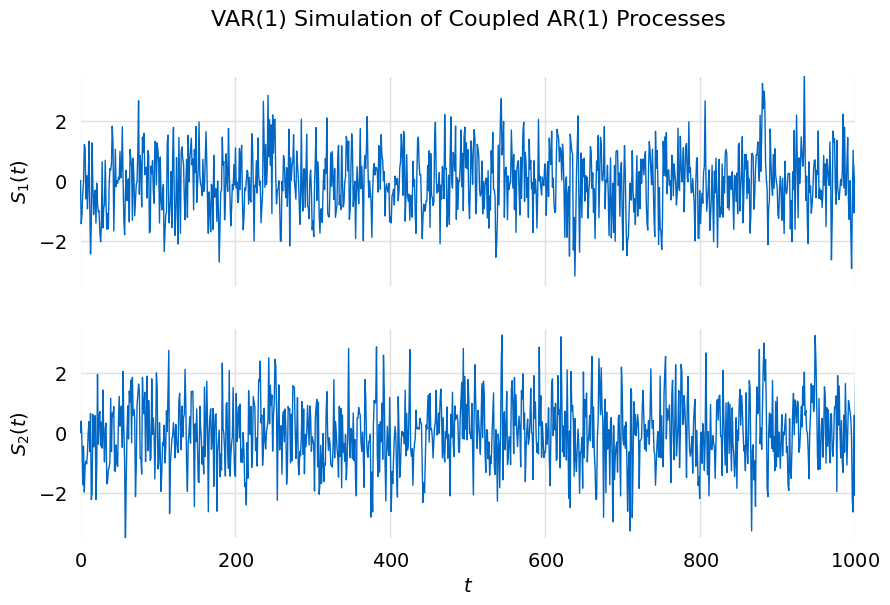

In [14]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [15]:
result, result_model = var.compute_order_estimate(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.3024,0.3050,1.353,0.3033
1,-0.03868*,-0.03085*,0.9621*,-0.03594*
2,-0.03760,-0.02455,0.9631,-0.03302
3,-0.03681,-0.01855,0.9639,-0.03041
4,-0.03570,-0.01222,0.9649,-0.02747


In [16]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderEst__est_id": "8c3c6015-4876-46ca-ae38-630b9e01c33b",
   "_VAROrderEst__order": 1,
   "_VAROrderEst__aic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "AIC",
      "_LagOrderEst__value": -0.03868068474011059,
      "_LagOrderEst__est_id": "8c3c6015-4876-46ca-ae38-630b9e01c33b"
   },
   "_VAROrderEst__bic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "BIC",
      "_LagOrderEst__value": -0.03085475254886303,
      "_LagOrderEst__est_id": "8c3c6015-4876-46ca-ae38-630b9e01c33b"
   },
   "_VAROrderEst__fpe": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "FPE",
      "_LagOrderEst__value": 0.9620578601380905,
      "_LagOrderEst__est_id": "8c3c6015-4876-46ca-ae38-630b9e01c33b"
   },
   "_VAROrderEst__hqic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "HQIC",
      "_LagOrderEst__value": -0.03593770744801816,
      "_LagOrderEst__est_id": "8c3c6015-4876-46ca-ae38-630b9e01c33b"


In [17]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 18, Nov, 2023
Time:                     15:11:38
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                 -0.0312153
Nobs:                     4999.00    HQIC:                -0.0362957
Log likelihood:          -14083.0    FPE:                   0.961715
AIC:                   -0.0390372    Det(Omega_mle):        0.960562
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.017619         0.013969           -1.261           0.207
L1.y1         0.238452         0.013841           17.227           0.000
L1.y2         0.050719         0.012257            4.138           0.000

Results for equation 

In [18]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.017618599084358293,
         "err": 0.013969479358172505,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "c2af2e0a-3cdc-4da5-ab95-1f52da65037b",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.004480779737486248,
         "err": 0.014049575184937931,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "c2af2e0a-3cdc-4da5-ab95-1f52da65037b",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 1,
   "_VAREst__params": [
      {
         "est": 0.23845184886106388,
         "err": 0.013841370702444025,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order":

### Coupled $\text{AR}(1)$ With Non Unit Normal Noise

In [19]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[2.0, 0.2],
                      [0.2, 2.0]])
npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [20]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

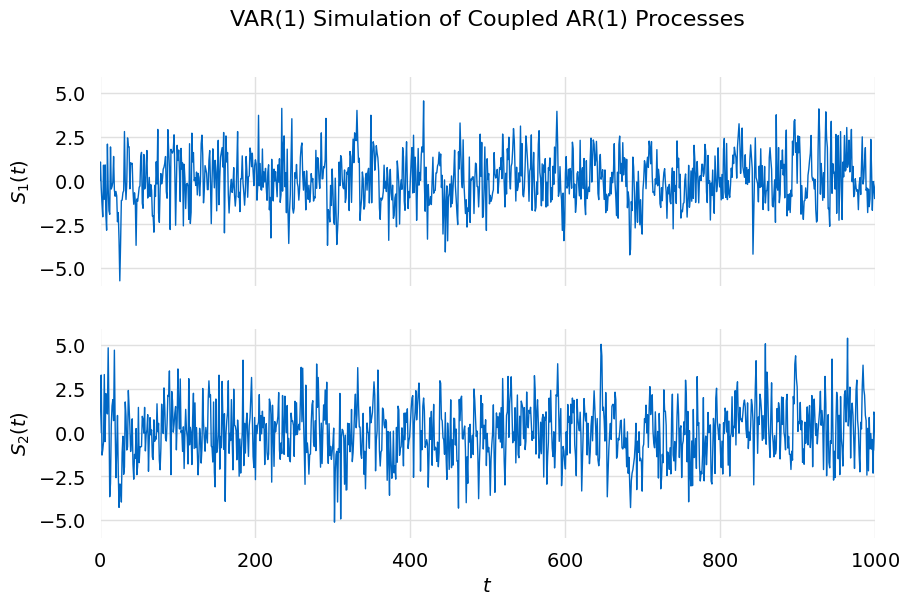

In [21]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

In [22]:
result, result_model = var.compute_order_estimate(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,1.734,1.736,5.662,1.735
1,1.401*,1.408*,4.058*,1.403*
2,1.401,1.414,4.060,1.406
3,1.401,1.420,4.061,1.408
4,1.402,1.425,4.063,1.410


In [23]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderEst__est_id": "c2fd52b3-e659-4c02-83dd-62ef47db07b1",
   "_VAROrderEst__order": 1,
   "_VAROrderEst__aic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "AIC",
      "_LagOrderEst__value": 1.4005894061966015,
      "_LagOrderEst__est_id": "c2fd52b3-e659-4c02-83dd-62ef47db07b1"
   },
   "_VAROrderEst__bic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "BIC",
      "_LagOrderEst__value": 1.408415338387849,
      "_LagOrderEst__est_id": "c2fd52b3-e659-4c02-83dd-62ef47db07b1"
   },
   "_VAROrderEst__fpe": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "FPE",
      "_LagOrderEst__value": 4.057590832530951,
      "_LagOrderEst__est_id": "c2fd52b3-e659-4c02-83dd-62ef47db07b1"
   },
   "_VAROrderEst__hqic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "HQIC",
      "_LagOrderEst__value": 1.403332383488694,
      "_LagOrderEst__est_id": "c2fd52b3-e659-4c02-83dd-62ef47db07b1"
   }
}


In [24]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 18, Nov, 2023
Time:                     15:11:39
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    1.40872
Nobs:                     4999.00    HQIC:                   1.40364
Log likelihood:          -17682.1    FPE:                    4.05886
AIC:                      1.40090    Det(Omega_mle):         4.05399
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.013692         0.020198            0.678           0.498
L1.y1         0.250154         0.013988           17.884           0.000
L1.y2         0.037609         0.012561            2.994           0.003

Results for equation 

In [25]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.013691850888083192,
         "err": 0.020197785747980243,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "729fde2f-6437-4d15-a124-0be09d433b11",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.004323633628307691,
         "err": 0.02005006501675748,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "729fde2f-6437-4d15-a124-0be09d433b11",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 1,
   "_VAREst__params": [
      {
         "est": 0.2501544302480064,
         "err": 0.013987955671934478,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,

## $\text{VAR}(2)$ Simulations
### Uncoupled $\text{AR}(2)$

In [26]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]]),
        numpy.matrix([[0.5, 0.0],
                      [0.0, 0.5]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [27]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

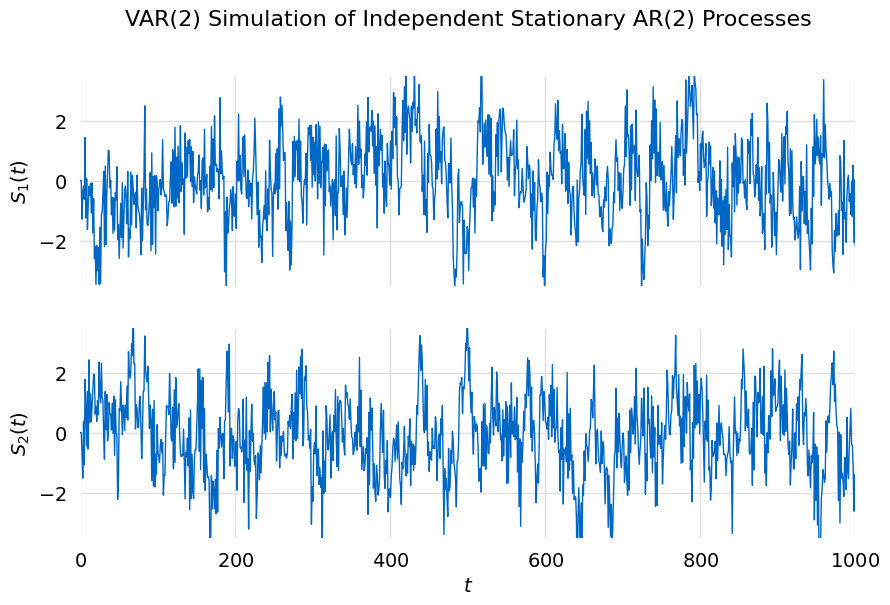

In [28]:
title = f"VAR(2) Simulation of Independent Stationary AR(2) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [29]:
result, result_model = var.compute_order_estimate(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,1.214,1.217,3.368,1.215
1,0.5894,0.5973,1.803,0.5922
2,0.02344*,0.03648*,1.024*,0.02801*
3,0.02368,0.04194,1.024,0.03008
4,0.02492,0.04840,1.025,0.03315


In [30]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderEst__est_id": "0ced0eea-7713-4b9d-8acc-21e4fb41909a",
   "_VAROrderEst__order": 2,
   "_VAROrderEst__aic": {
      "_LagOrderEst__order": 2,
      "_LagOrderEst__error_metric": "AIC",
      "_LagOrderEst__value": 0.02343567585566862,
      "_LagOrderEst__est_id": "0ced0eea-7713-4b9d-8acc-21e4fb41909a"
   },
   "_VAROrderEst__bic": {
      "_LagOrderEst__order": 2,
      "_LagOrderEst__error_metric": "BIC",
      "_LagOrderEst__value": 0.03647889617441455,
      "_LagOrderEst__est_id": "0ced0eea-7713-4b9d-8acc-21e4fb41909a"
   },
   "_VAROrderEst__fpe": {
      "_LagOrderEst__order": 2,
      "_LagOrderEst__error_metric": "FPE",
      "_LagOrderEst__value": 1.0237124505696256,
      "_LagOrderEst__est_id": "0ced0eea-7713-4b9d-8acc-21e4fb41909a"
   },
   "_VAROrderEst__hqic": {
      "_LagOrderEst__order": 2,
      "_LagOrderEst__error_metric": "HQIC",
      "_LagOrderEst__value": 0.028007304675822676,
      "_LagOrderEst__est_id": "0ced0eea-7713-4b9d-8acc-21e4fb41909a"
  

In [31]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 18, Nov, 2023
Time:                     15:11:40
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0364340
Nobs:                     4998.00    HQIC:                 0.0279652
Log likelihood:          -14232.2    FPE:                    1.02367
AIC:                    0.0233952    Det(Omega_mle):         1.02163
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.027319         0.014342           -1.905           0.057
L1.y1         0.248740         0.012163           20.451           0.000
L1.y2         0.011560         0.012497            0.925           0.355
L2.y1         0.511126

In [32]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.02731853907575398,
         "err": 0.014341986323978054,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "81594276-ab47-4fd1-ac38-f4078779a379",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.003411576468839211,
         "err": 0.014231852787673499,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "81594276-ab47-4fd1-ac38-f4078779a379",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 2,
   "_VAREst__params": [
      {
         "est": 0.2487400422744933,
         "err": 0.012162533225427501,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,

### Coupled $\text{AR}(2)$

In [33]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.15],
                      [0.1, 0.1]]),
        numpy.matrix([[0.25, 0.3],
                      [0.2, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [34]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

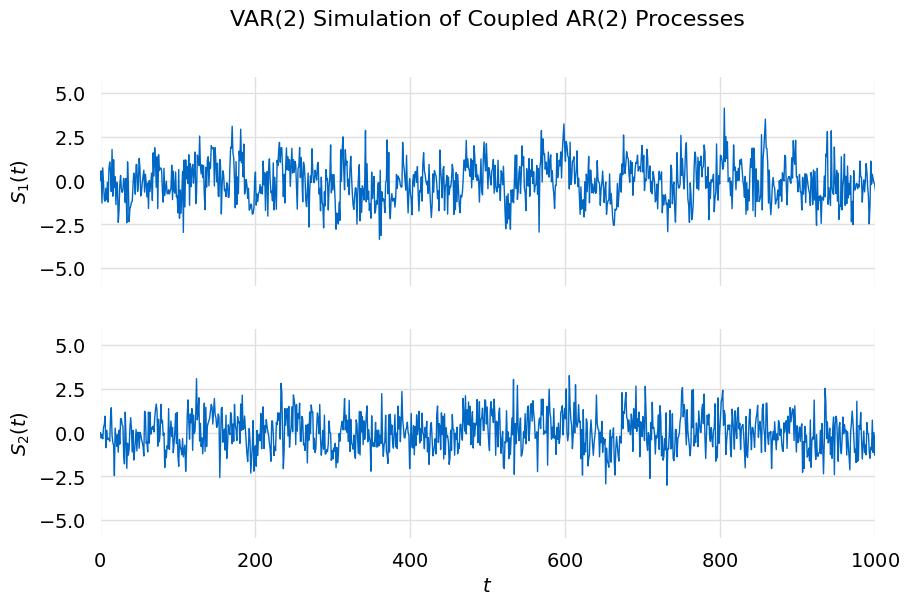

In [35]:
title = f"VAR(2) Simulation of Coupled AR(2) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

In [36]:
result, result_model = var.compute_order_estimate(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.4104,0.4130,1.507,0.4113
1,0.2109,0.2187,1.235,0.2136
2,-0.01662*,-0.003576*,0.9835*,-0.01205*
3,-0.01584,0.002419,0.9843,-0.009442
4,-0.01487,0.008610,0.9852,-0.006639


In [37]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderEst__est_id": "7283f08d-f35a-464f-8aee-ed6e43c74cee",
   "_VAROrderEst__order": 2,
   "_VAROrderEst__aic": {
      "_LagOrderEst__order": 2,
      "_LagOrderEst__error_metric": "AIC",
      "_LagOrderEst__value": -0.016618789284701403,
      "_LagOrderEst__est_id": "7283f08d-f35a-464f-8aee-ed6e43c74cee"
   },
   "_VAROrderEst__bic": {
      "_LagOrderEst__order": 2,
      "_LagOrderEst__error_metric": "BIC",
      "_LagOrderEst__value": -0.0035755689659554696,
      "_LagOrderEst__est_id": "7283f08d-f35a-464f-8aee-ed6e43c74cee"
   },
   "_VAROrderEst__fpe": {
      "_LagOrderEst__order": 2,
      "_LagOrderEst__error_metric": "FPE",
      "_LagOrderEst__value": 0.9835185423017713,
      "_LagOrderEst__est_id": "7283f08d-f35a-464f-8aee-ed6e43c74cee"
   },
   "_VAROrderEst__hqic": {
      "_LagOrderEst__order": 2,
      "_LagOrderEst__error_metric": "HQIC",
      "_LagOrderEst__value": -0.012047160464547346,
      "_LagOrderEst__est_id": "7283f08d-f35a-464f-8aee-ed6e43c74c

In [38]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 18, Nov, 2023
Time:                     15:11:40
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                -0.00394969
Nobs:                     4998.00    HQIC:                -0.0124185
Log likelihood:          -14131.3    FPE:                   0.983155
AIC:                   -0.0169885    Det(Omega_mle):        0.981191
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.016051         0.014260           -1.126           0.260
L1.y1         0.152571         0.013085           11.660           0.000
L1.y2         0.111232         0.014100            7.889           0.000
L2.y1         0.254006

In [39]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.016050793311334497,
         "err": 0.014260244469802636,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "2cec3acf-5162-497c-8248-534beb5f3e1e",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.00813608848690126,
         "err": 0.013913573446270417,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "2cec3acf-5162-497c-8248-534beb5f3e1e",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 2,
   "_VAREst__params": [
      {
         "est": 0.15257135791613796,
         "err": 0.01308526438597573,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,

## $\text{VAR}(3)$ Simulations
### Uncoupled $\text{AR}(3)$

In [40]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.05, 0.0, 0.0],
                      [0.0, 0.1, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
var.compute_is_stationary(phi)
npts=5000
nlag=3

In [41]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

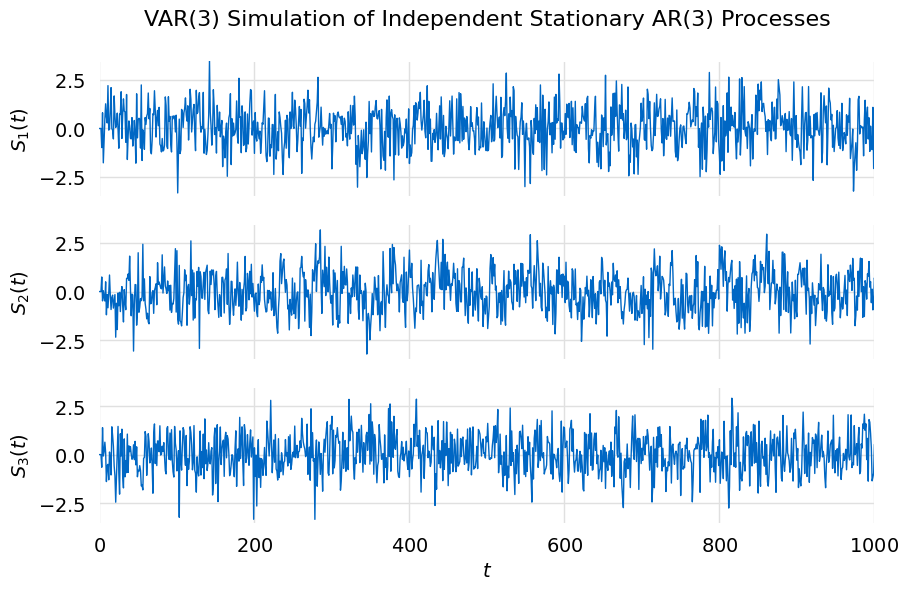

In [42]:
title = f"VAR(3) Simulation of Independent Stationary AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [43]:
result, result_model = var.compute_order_estimate(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.1506,0.1545,1.163,0.1520
1,0.08199,0.09764,1.085,0.08748
2,0.05922,0.08661,1.061,0.06882
3,0.01053*,0.04966*,1.011*,0.02424*
4,0.01338,0.06425,1.013,0.03121


In [44]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderEst__est_id": "26364452-8af9-4b13-8102-fdf30fb1b949",
   "_VAROrderEst__order": 3,
   "_VAROrderEst__aic": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "AIC",
      "_LagOrderEst__value": 0.01052987110408902,
      "_LagOrderEst__est_id": "26364452-8af9-4b13-8102-fdf30fb1b949"
   },
   "_VAROrderEst__bic": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "BIC",
      "_LagOrderEst__value": 0.049659532060326826,
      "_LagOrderEst__est_id": "26364452-8af9-4b13-8102-fdf30fb1b949"
   },
   "_VAROrderEst__fpe": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "FPE",
      "_LagOrderEst__value": 1.010585521507262,
      "_LagOrderEst__est_id": "26364452-8af9-4b13-8102-fdf30fb1b949"
   },
   "_VAROrderEst__hqic": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "HQIC",
      "_LagOrderEst__value": 0.024244757564551196,
      "_LagOrderEst__est_id": "26364452-8af9-4b13-8102-fdf30fb1b949"
  

In [45]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 18, Nov, 2023
Time:                     15:11:41
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  0.0494549
Nobs:                     4997.00    HQIC:                 0.0240443
Log likelihood:          -21267.1    FPE:                    1.01039
AIC:                    0.0103319    Det(Omega_mle):         1.00434
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.012636         0.014317            0.883           0.377
L1.y1         0.127209         0.014018            9.074           0.000
L1.y2        -0.006933         0.014216           -0.488           0.626
L1.y3        -0.005005

In [46]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.012636352625704964,
         "err": 0.014317263100654534,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "bb18c0a7-b8e9-4858-8715-4895f8313a10",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.006643845465564956,
         "err": 0.01408903812468549,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "bb18c0a7-b8e9-4858-8715-4895f8313a10",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.002107527491944647,
         "err": 0.014098516529031857,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 2,
         "order": 1,
         "est_id": "bb18c0a7-b8e9-4858-8715-4895f8313a10

### Coupled $\text{AR}(3)$

In [47]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.1, 0.2],
                      [0.0, 0.15, 0.1],
                      [0.05, 0.025, 0.05]]),
        numpy.matrix([[0.015, 0.01, 0.0],
                      [0.1, 0.1, 0.05],
                      [0.1, 0.05, 0.05]]),
        numpy.matrix([[0.15, 0.05, 0.1],
                      [0.0, 0.15, 0.025],
                      [0.025, 0.15, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
npts=5000
nlag=11
var.compute_is_stationary(phi)


True

In [48]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

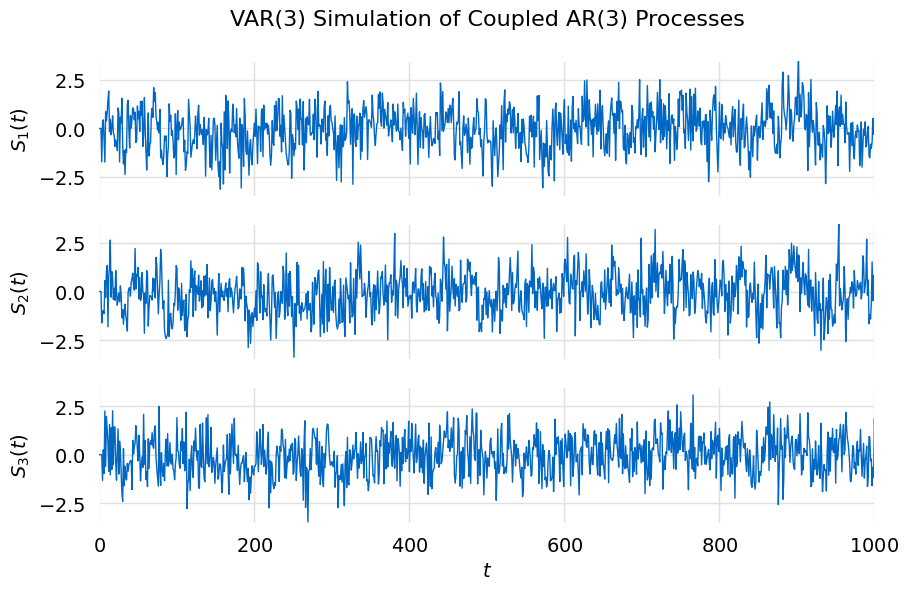

In [49]:
title = f"VAR(3) Simulation of Coupled AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [50]:
result, result_model = var.compute_order_estimate(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.3784,0.3824,1.460,0.3798
1,0.1643,0.1799,1.179,0.1698
2,0.09464,0.1220,1.099,0.1042
3,0.01120*,0.05033*,1.011*,0.02491*
4,0.01284,0.06371,1.013,0.03067


In [51]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderEst__est_id": "742ba749-e747-416a-9e52-196f59ce03a5",
   "_VAROrderEst__order": 3,
   "_VAROrderEst__aic": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "AIC",
      "_LagOrderEst__value": 0.01119983707729327,
      "_LagOrderEst__est_id": "742ba749-e747-416a-9e52-196f59ce03a5"
   },
   "_VAROrderEst__bic": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "BIC",
      "_LagOrderEst__value": 0.050329498033531074,
      "_LagOrderEst__est_id": "742ba749-e747-416a-9e52-196f59ce03a5"
   },
   "_VAROrderEst__fpe": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "FPE",
      "_LagOrderEst__value": 1.011262806273225,
      "_LagOrderEst__est_id": "742ba749-e747-416a-9e52-196f59ce03a5"
   },
   "_VAROrderEst__hqic": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "HQIC",
      "_LagOrderEst__value": 0.024914723537755444,
      "_LagOrderEst__est_id": "742ba749-e747-416a-9e52-196f59ce03a5"
  

In [52]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 18, Nov, 2023
Time:                     15:11:42
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   0.157613
Nobs:                     4989.00    HQIC:                 0.0711031
Log likelihood:          -21196.2    FPE:                    1.02471
AIC:                    0.0244138    Det(Omega_mle):         1.00405
--------------------------------------------------------------------
Results for equation y1
            coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------
const         -0.008406         0.014363           -0.585           0.558
L1.y1          0.172137         0.014207           12.117           0.000
L1.y2          0.103456         0.014303            7.233           0.000
L1.y3          0.

In [53]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.008406493914275618,
         "err": 0.014362653134397331,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "e3e617c2-66dd-4928-a8de-5db784f915bd",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.01048689501030043,
         "err": 0.014261096767037995,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "e3e617c2-66dd-4928-a8de-5db784f915bd",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.016434722620608057,
         "err": 0.013992312134249481,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 2,
         "order": 1,
         "est_id": "e3e617c2-66dd-4928-a8de-5db784f915b